# Forest fire and smoke detection: quick start (no training)

This notebook **loads the already-trained model** and uses it. It does **not** train anything, so it runs in about a minute
(the full training notebook, `forest_fire_vit_detection.ipynb`, takes several hours).

What it does:
1. Gets the repository and the final model (about 424 MB) if they are not already here.
2. Loads the model and shows the results saved with it (test mAP@0.50 = 78.07%), plus the saved plots and confusion matrix.
3. Runs the detector on example images. With the D-Fire dataset available it uses test images and draws the ground truth
   (white dashed) next to the predictions; you can also put your own image paths in `MY_IMAGES`.

Works on your own computer (after `git clone`), on Kaggle, or on Colab. A GPU is used if there is one, otherwise the CPU (slower).
The D-Fire dataset is optional: it is only needed for the test-image examples and the optional confusion-matrix run at the end.

In [1]:
import os, sys, subprocess, urllib.request
from pathlib import Path

REPO = "https://github.com/GeetanjaliPunna05/Forest-Fire-Detection.git"
MODEL_URL = ("https://media.githubusercontent.com/media/GeetanjaliPunna05/Forest-Fire-Detection/"
             "main/outputs/forest_fire_detection_best.pth")

# 1) Find the repository folder (this notebook may already be inside it); otherwise clone it.
here = Path.cwd()
root = next((p for p in (here, here.parent) if (p / "predict.py").exists()), None)
if root is None:
    subprocess.run(["git", "clone", "-q", REPO], check=True)
    root = here / "Forest-Fire-Detection"
os.chdir(root)
sys.path.insert(0, str(root))

# 2) Python packages (only installs what is missing).
try:
    import timm, cv2, torchvision
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "timm>=1.0", "opencv-python-headless"], check=True)

# 3) The model file. A plain git clone only contains a tiny placeholder for it, so download the real file if needed.
MODEL_PATH = root / "outputs" / "forest_fire_detection_best.pth"
MODEL_PATH.parent.mkdir(exist_ok=True)
if not MODEL_PATH.exists() or MODEL_PATH.stat().st_size < 10_000_000:
    print("Downloading the model (about 424 MB) ...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
print("Repository:", root.name, "| model:", MODEL_PATH.relative_to(root), f"({MODEL_PATH.stat().st_size / 1e6:.0f} MB)")

Repository: Project | model: outputs\forest_fire_detection_best.pth (424 MB)


C:\fire_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load the trained model and its saved results

In [2]:
import torch, pandas as pd
from IPython.display import Image, display
from predict import FireSmokeDetector

ck = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
print(f"Best epoch: {ck['epoch']} | validation mAP@0.50: {ck['val_mAP50']:.2f}% | "
      f"confidence threshold {ck['conf_threshold']:.2f} | NMS IoU {ck['nms_iou']}")

detector = FireSmokeDetector(str(MODEL_PATH))          # weights + settings are all inside the file
print("Model loaded on:", detector.device.type.upper())

r = ck["results"]
rows = []
for name in ("smoke", "fire", "overall"):
    m = r["test_precision_recall_f1"][name]
    rows.append({"class": name, "Precision": m["P"], "Recall": m["R"], "F1": m["F1"],
                 "AP@50": r["test_AP50"].get(name, r["test_mAP50"])})
print(f"\nSaved TEST results ({r['test_images']} images): mAP@0.50 = {r['test_mAP50']:.2f}%, mAP@0.50:0.95 = {r['test_mAP50_95']:.2f}%")
display(pd.DataFrame(rows).set_index("class").round(2))

Best epoch: 10 | validation mAP@0.50: 79.15% | confidence threshold 0.82 | NMS IoU 0.5


Model loaded on: CUDA

Saved TEST results (4306 images): mAP@0.50 = 78.07%, mAP@0.50:0.95 = 41.22%


,Precision,Recall,F1,AP@50
class,,,,
smoke,82.35,83.56,82.95,85.33
fire,73.04,65.43,69.02,70.81
overall,77.69,74.49,75.99,78.07


### Saved plots (already computed, nothing is re-run here)

outputs/training_curves.png


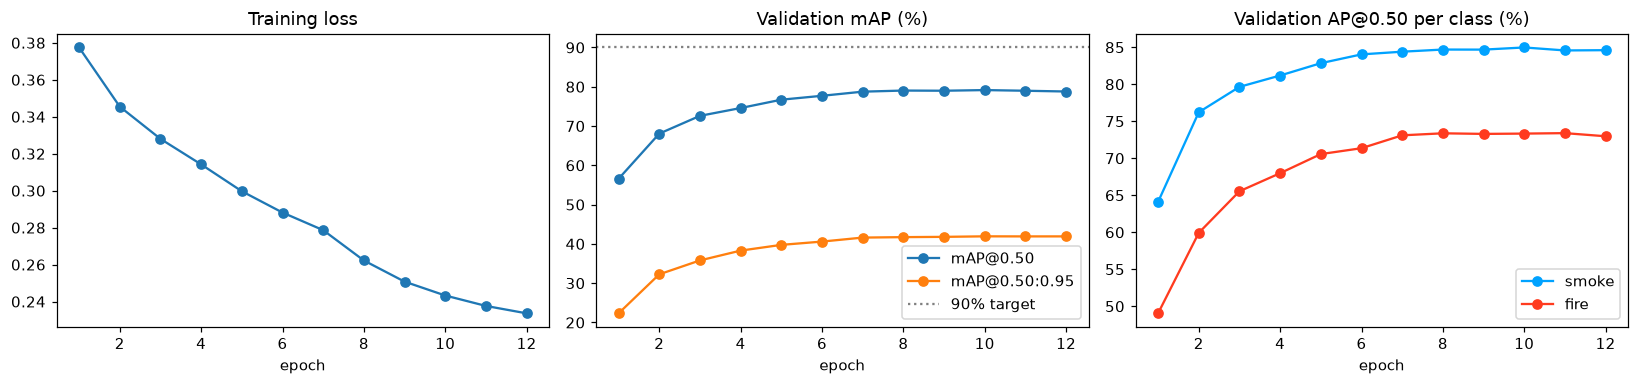

outputs/test_pr_f1_curves.png


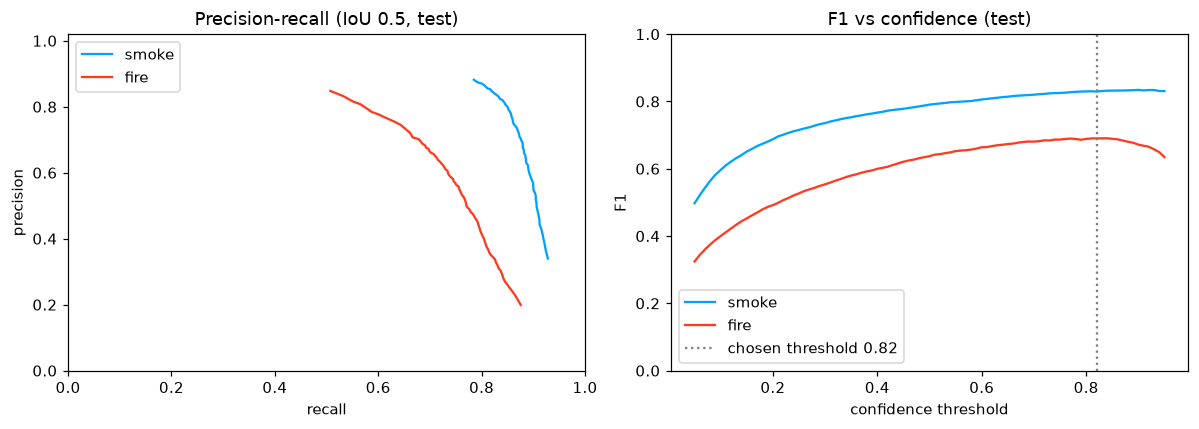

deliverables/confusion_matrix.png


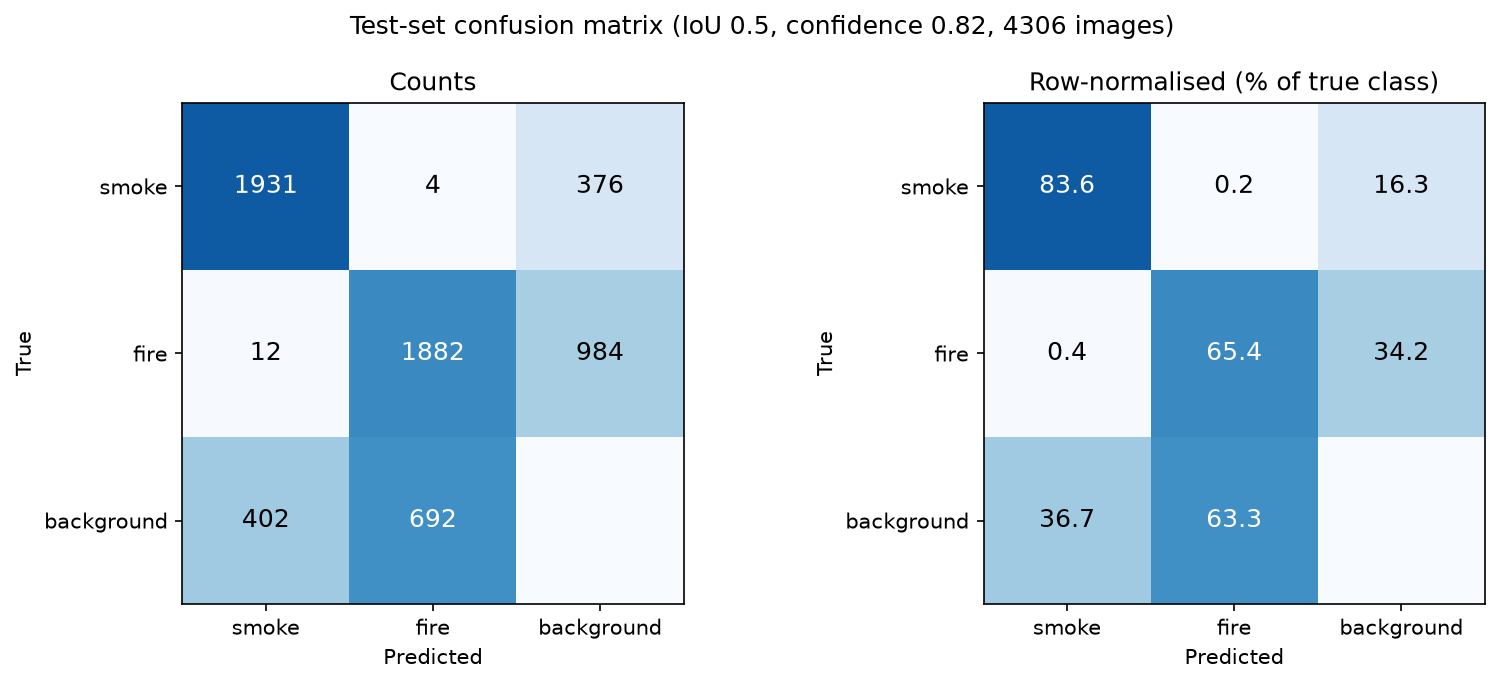

In [3]:
for f in ("outputs/training_curves.png", "outputs/test_pr_f1_curves.png", "deliverables/confusion_matrix.png"):
    if (root / f).exists():
        print(f); display(Image(filename=str(root / f)))

## 2. Try it on images

Set `MY_IMAGES` to your own image paths, for example `MY_IMAGES = ["photo1.jpg", "photo2.png"]`.
If it is left empty, the notebook uses a few D-Fire **test** images when the dataset is found (`./data`, the `DATA_ROOT`
environment variable, or `/kaggle/input`). Boxes: **blue = smoke, red = fire**, white dashed = ground truth (dataset images only).

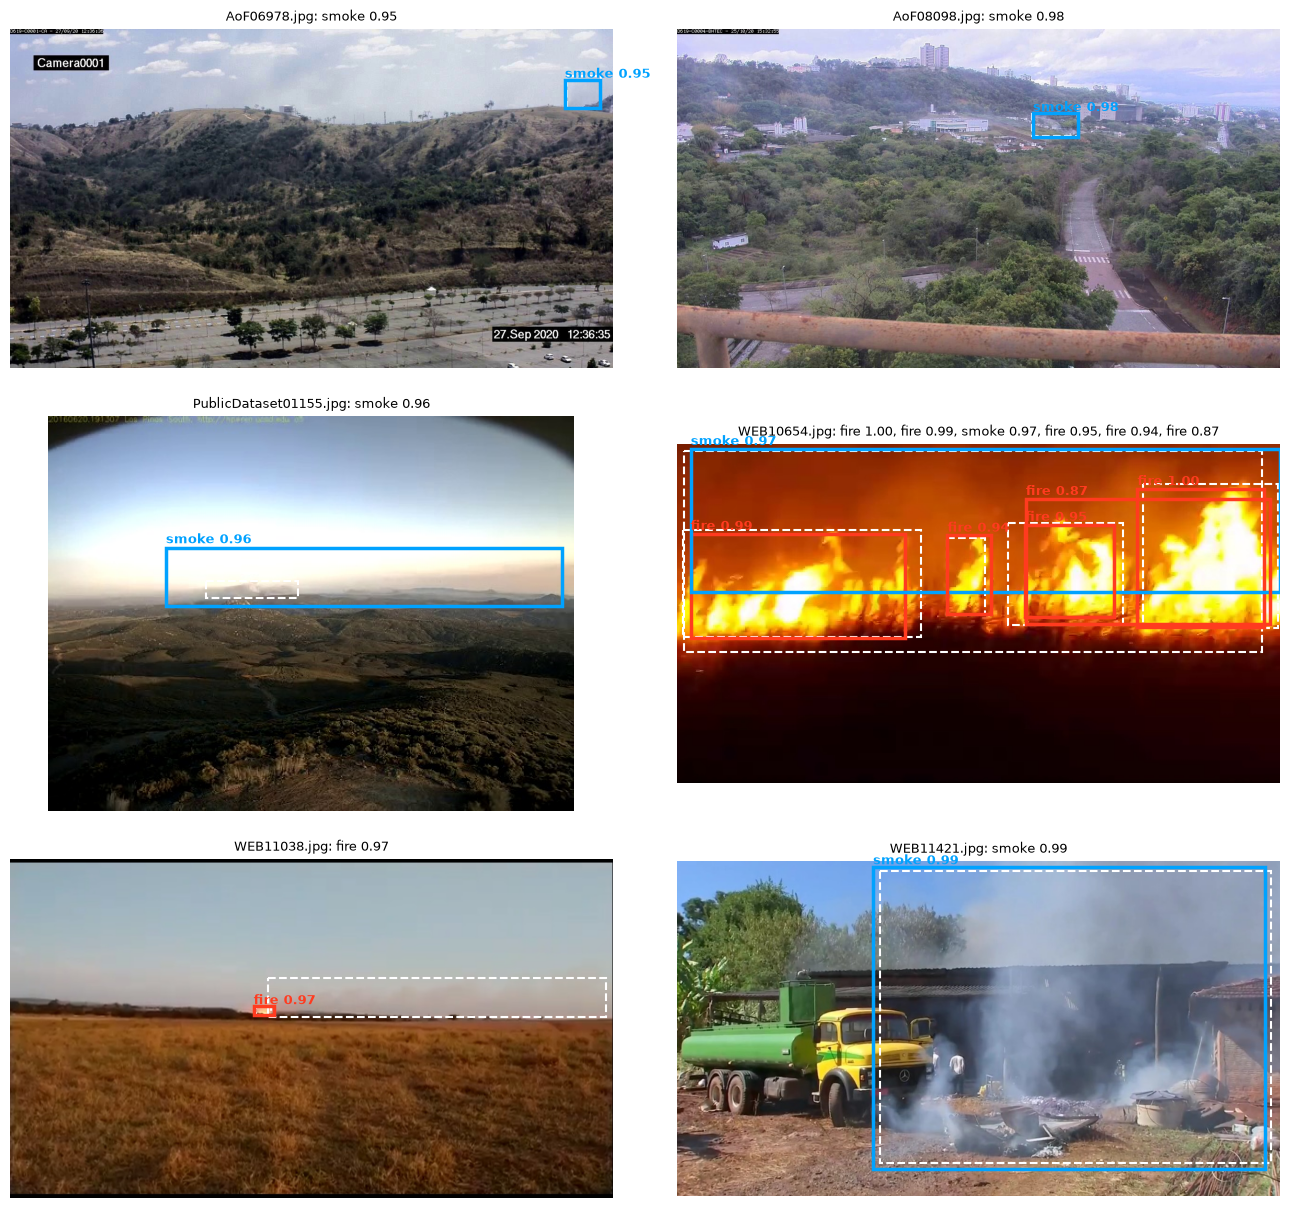

In [4]:
import numpy as np, cv2, matplotlib.pyplot as plt, matplotlib.patches as patches

MY_IMAGES = []            # <- put your own image paths here

COLORS = {"smoke": "#00a2ff", "fire": "#ff3b1f"}

def find_data_root():
    cands = [Path(os.environ["DATA_ROOT"])] if os.environ.get("DATA_ROOT") else []
    cands.append(root / "data")
    for base in cands:
        if (base / "test" / "images").is_dir():
            return base
    if os.path.isdir("/kaggle/input"):
        for cur, dirs, _ in os.walk("/kaggle/input"):
            if cur.count(os.sep) - 2 >= 5:
                dirs[:] = []
            if (Path(cur) / "test" / "images").is_dir():
                return Path(cur)
    return None

def gt_boxes(img_path, w, h):
    lab = Path(img_path).parent.parent / "labels" / (Path(img_path).stem + ".txt")
    out = []
    if lab.exists():
        for line in lab.read_text().splitlines():
            p = line.split()
            if len(p) == 5:
                cx, cy, bw, bh = map(float, p[1:])
                out.append(((cx - bw / 2) * w, (cy - bh / 2) * h, (cx + bw / 2) * w, (cy + bh / 2) * h))
    return out

def show(paths, conf=None):
    n = len(paths); rows = (n + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(13, 4.2 * rows)); axes = np.atleast_1d(axes).ravel()
    for ax, p in zip(axes, paths):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB); h, w = img.shape[:2]
        dets = detector(p, conf=conf)
        ax.imshow(img); ax.axis("off")
        for x1, y1, x2, y2 in gt_boxes(p, w, h):
            ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec="white", ls="--", lw=1.5))
        for d in dets:
            x1, y1, x2, y2 = d["box"]
            ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, ec=COLORS[d["label"]], lw=2.5))
            ax.text(x1, max(y1 - 4, 0), f'{d["label"]} {d["confidence"]:.2f}', color=COLORS[d["label"]], fontsize=9, weight="bold")
        ax.set_title(f"{Path(p).name}: " + (", ".join(f'{d["label"]} {d["confidence"]:.2f}' for d in dets) or "nothing detected"), fontsize=9)
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

images = [str(p) for p in MY_IMAGES]
if not images:
    data_root = find_data_root()
    if data_root is None:
        print("D-Fire data not found. Put your own image paths in MY_IMAGES above and run this cell again.")
    else:
        labels = [l for l in sorted((data_root / "test" / "labels").glob("*.txt")) if l.stat().st_size > 0]
        for l in labels[::max(len(labels) // 6, 1)][:6]:
            images += [str(q) for q in (data_root / "test" / "images").glob(l.stem + ".*")][:1]
if images:
    show(images)

## 3. Optional: recompute the confusion matrix (needs the D-Fire data)

The saved confusion matrix is shown in section 1. Set the flag below to `True` to recompute it from the model on all 4,306 test
images (about 3 minutes on a GPU; needs the D-Fire dataset). It writes `deliverables/confusion_matrix.png` and `.csv`.

In [5]:
RUN_CONFUSION_MATRIX = False

if RUN_CONFUSION_MATRIX:
    subprocess.run([sys.executable, "deliverables/make_confusion_matrix.py"], check=True)
    display(Image(filename="deliverables/confusion_matrix.png"))
else:
    print("Skipped (set RUN_CONFUSION_MATRIX = True to run it).")

Skipped (set RUN_CONFUSION_MATRIX = True to run it).
